<a href="https://colab.research.google.com/github/tsakailab/MultivariateAnalysis/blob/main/ipynb/ex_Multicollinearity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 例題で理解する多重共線性

---
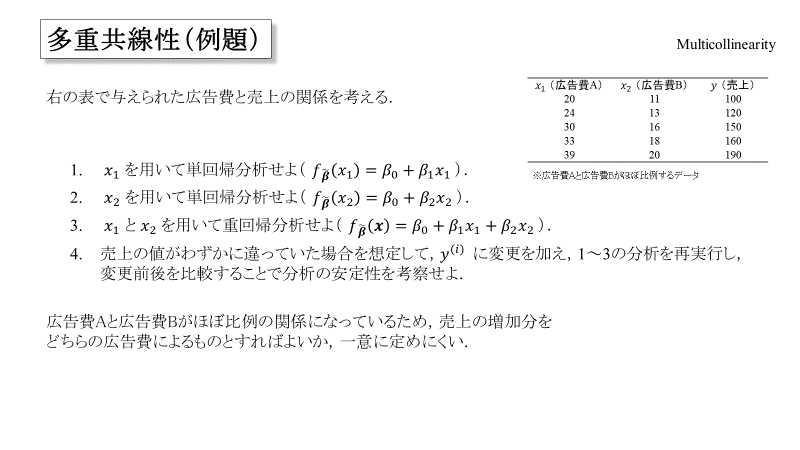

---
[解説記事](https://gemini.google.com/share/ef995e3e4f45)

In [ ]:
import pandas as pd

# データの準備
data = {'広告費A x1': [20, 24, 30, 33, 39], '広告費B x2': [11, 13, 16, 18, 20],
             '売上 y': [100, 120, 150, 160, 190]}
df = pd.DataFrame(data)

# データの表を表示
print("データ例：広告費と売上の関係")
print(df)

x_data = df[['広告費A x1', '広告費B x2']].values.copy()  # 説明変数 (特徴量)
y_data = df['売上 y'].values.copy()  # 目的変数 (ターゲット)

df_corr = df.corr()
print("\n相関係数\n", df_corr)

In [ ]:
import numpy as np

# 1. x1 用いた単回帰
print("x1 を用いた単回帰")

xs, ys = x_data[:, 0], y_data
X = np.column_stack((np.ones(len(xs)), xs))
print("計画行列:\n", X)

beta = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(ys))
print(pd.DataFrame({'beta': beta}))

delta = ys - X.dot(beta)
rss = (delta**2).sum()
print('Residual Sum of Squares: RSS =', rss)
print('決定係数 =', 1 - rss/(((ys - ys.mean()) ** 2).sum()))

# 2. x2 用いた単回帰
print("x2 を用いた単回帰")

xs, ys = x_data[:, 1], y_data
X = np.column_stack((np.ones(len(xs)), xs))
print("計画行列:\n", X)

beta = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(ys))
print(pd.DataFrame({'beta': beta}))

delta = ys - X.dot(beta)
rss = (delta**2).sum()
print('Residual Sum of Squares: RSS =', rss)
print('決定係数 =', 1 - rss/(((ys - ys.mean()) ** 2).sum()))


# 3. x1 と x2 用いた重回帰
print("x1 と x2 を用いた重回帰")

xs, ys = x_data[:, :2], y_data
X = np.column_stack((np.ones(len(xs)), xs))
print("計画行列:\n", X)

beta = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(ys))
print(pd.DataFrame({'beta': beta}))

delta = ys - X.dot(beta)
rss = (delta**2).sum()
print('Residual Sum of Squares: RSS =', rss)
print('決定係数 =', 1 - rss/(((ys - ys.mean()) ** 2).sum()))

In [ ]:
# sklearnの場合
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# 1. x1 用いた単回帰
print("x1 を用いた単回帰")
xs, ys = x_data[:, 0].reshape(-1,1), y_data
model.fit(xs, ys)
print(model.intercept_, *model.coef_)
print('決定係数 =', model.score(xs,ys))

# 2. x1 用いた単回帰
print("x2 を用いた単回帰")
xs, ys = x_data[:, 1].reshape(-1,1), y_data
model.fit(xs, ys)
print(model.intercept_, *model.coef_)
print('決定係数 =', model.score(xs,ys))

# 3. x1 と x2 用いた重回帰
print("x1 と x2 を用いた重回帰")
xs, ys = x_data[:, :2].reshape(-1,2), y_data
model.fit(xs, ys)
print(model.intercept_, *model.coef_)
print('決定係数 =', model.score(xs,ys))


In [ ]:
print(df['売上 y'].values)

# 4. 売上の値がわずかに違っていた場合を想定する
y_data[3] = df['売上 y'].values[3] + 3 # 例
print(y_data)

In [ ]:
# x1 と x2 用いた重回帰を再実行
print("x1 と x2 を用いた重回帰")
xs, ys = x_data[:, :2].reshape(-1,2), y_data
model.fit(xs, ys)
print(model.intercept_, *model.coef_)
print('決定係数 =', model.score(xs,ys))

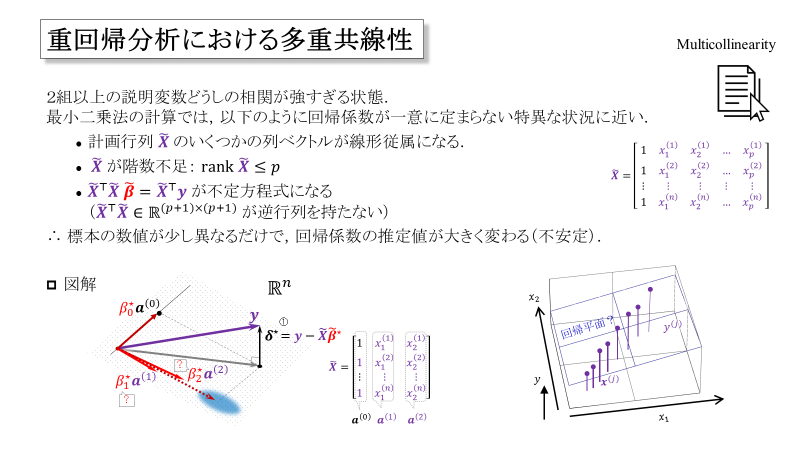